In [2]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 17.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
dtype = torch.float64
torch.set_default_dtype(dtype)

Using device: cpu


In [45]:
#@title GT functions

def f1(x, A=1.0, tau=1.6, offset=0.05):
    """
    Monotonic increasing function with saturation.
    """
    return offset + A * (1.0 - np.exp(-x / tau))

def f2(x, L=1.0, x0=2.5, k=3.0, offset=0.05):
    """
    Sigmoid-like transition.
    """
    return offset + L / (1 + np.exp(-k * (x - x0)))

def f3(x, x0=2.5, gamma=0.25, A=1.0, offset=0.05):
    """
    Lorentzian resonance peak.
    """
    return offset + A * gamma**2 / ((x - x0)**2 + gamma**2)

def f4(x, A=1.0, gamma=0.35, w=4.0, offset=0.0):
    """
    Damped oscillatory response.
    """
    return offset + A * np.exp(-gamma * x) * np.cos(w * x)

In [7]:
#@title auxilary functions

def generate_experiment_data(f_true, x_grid, n_points=9, noise_std=0.05, seed=None, plot=True):
    """
    Generate sparse noisy experimental observations from a ground truth function.

    Parameters
    ----------
    f_true : function
        Ground truth function f(x)
    x_grid : array
        Dense grid of x values
    n_train : int
        Number of experimental points
    noise_std : float
        Standard deviation of Gaussian noise
    seed : int or None
        Random seed for reproducibility
    plot : bool
        Whether to visualize the data

    Returns
    -------
    x_train, y_train
    """

    if seed is not None:
        np.random.seed(seed)

    idx = np.sort(np.random.choice(np.arange(len(x_grid)), size=n_points, replace=False))
    x_train = x_grid[idx]
    y_train = f_true(x_train) + np.random.normal(0, noise_std, size=n_points)

    if plot:
        plt.figure(figsize=(7,4))
        plt.plot(x_grid, f_true(x_grid), label="True function")
        plt.scatter(x_train, y_train, color="red", s=60, label="Observed points", zorder=3)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.show()

    return x_train, y_train

In [18]:
#@title GP model

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=200, plot=True):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    if plot:
        plt.figure(figsize=(6, 3))
        plt.plot(losses)
        plt.xlabel("Iteration")
        plt.ylabel("Negative log marginal likelihood")
        plt.title("Training loss")
        plt.show()

    return losses

# Hackathon Task

The objective is to explore an alternative workflow for interpreting sparse experimental data using Gaussian Processes (GP).


Instead of relying solely on the most probable GP prediction (i.e., the posterior mean), we consider the following approach:

1. Fit a GP model to a small set of noisy observations.
2. Draw multiple candidate functions from the GP posterior (Thompson-style sampling).
3. Treat these sampled functions as plausible hypotheses consistent with the data.
4. Select the final candidate based on external criteria such as known physics, constraints, or expected qualitative behavior.


In this notebook we implement the first three steps of this workflow.
The goal of the hackathon is to develop possible realizations of Step 4:
designing criteria or algorithms for ranking and selecting the most meaningful prediction from the GP posterior.


**Please, do not forget to submit your result. A short YouTube tutorial from Utkarsh explaining how to submit your results:**
https://www.youtube.com/watch?v=QcwQkAocrDY&t=35s

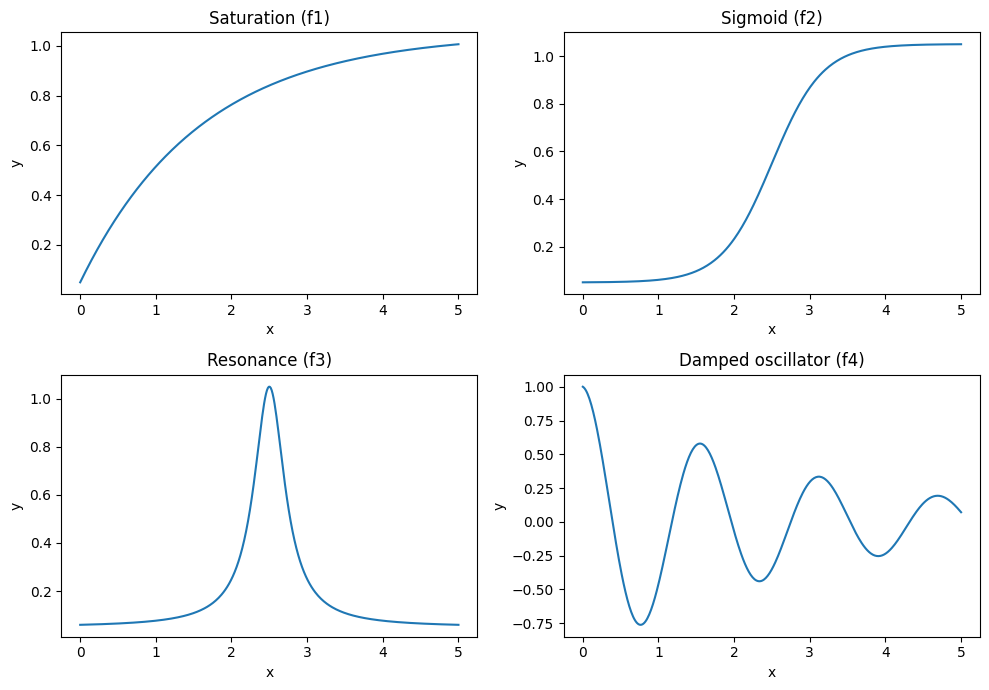

In [56]:
x_grid = np.linspace(0.0, 5.0, 400)
y1 = f1(x_grid)
y2 = f2(x_grid)
y3 = f3(x_grid)
y4 = f4(x_grid)

fig, ax = plt.subplots(2,2, figsize = (10,7))

for ax_ ,yy in zip(ax.flatten(), [y1, y2, y3, y4]):
  ax_.plot(x_grid, yy)
  ax_.set_xlabel("x")
  ax_.set_ylabel("y")

for ax_ ,ttl in zip(ax.flatten(), ['Saturation (f1)', 'Sigmoid (f2)', 'Resonance (f3)', 'Damped oscillator (f4)']):
  ax_.set_title(ttl)

plt.tight_layout()
# plt.show()

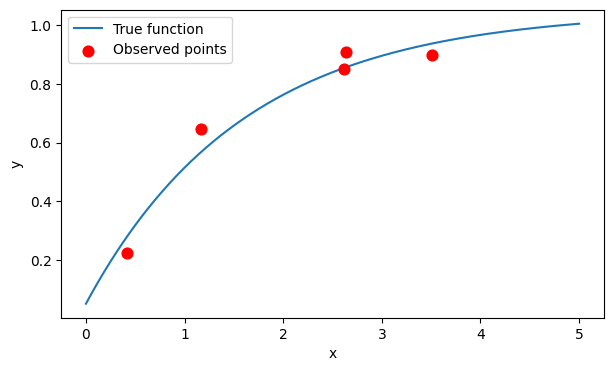

In [77]:
#choose function
f= f1

x_exp, y_exp = generate_experiment_data(f, x_grid, n_points=5, noise_std=0.1, seed=42)

#converting to torch.tensor
train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)

test_x = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

In [78]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

model = model.to(device=device, dtype=dtype)
likelihood = likelihood.to(device=device, dtype=dtype)



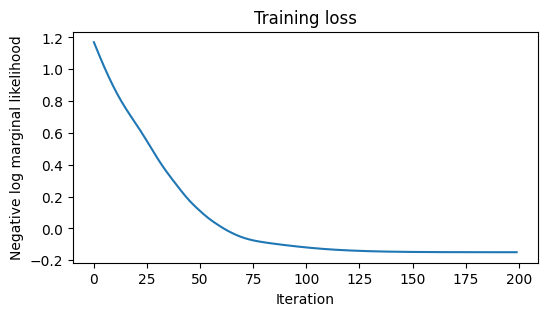

In [79]:
losses = train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=200, plot=True)

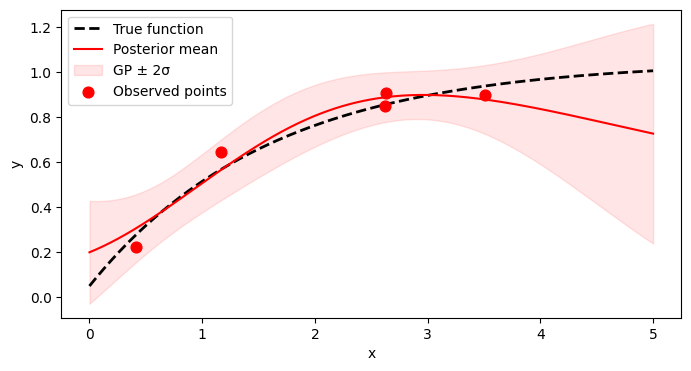

In [80]:
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    posterior = model(test_x)
    pred_mean = posterior.mean.cpu().numpy()
    pred_std = posterior.stddev.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(x_grid, f(x_grid), 'k--', label="True function", linewidth=2)
plt.plot(x_grid, pred_mean, 'r',label="Posterior mean", linestyle="-")
plt.fill_between(
    x_grid,
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    alpha=0.1,
    label="GP ± 2σ",
    color='r'
)
plt.scatter(x_exp, y_exp, color="red", s=60, label="Observed points", zorder=3)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [81]:
#Tompson sampling

n_candidates = 64 #number of the cundidate functions

with torch.no_grad():
    posterior = model(test_x)
    samples = posterior.sample(torch.Size([n_candidates]))

samples_np = samples.cpu().numpy() # - candidate function

/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


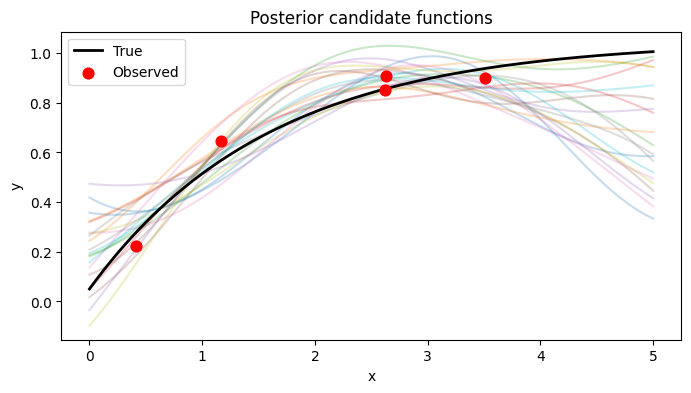

In [82]:
plt.figure(figsize=(8, 4))

for i in range(min(n_candidates, 20)):
    plt.plot(x_grid, samples_np[i], alpha=0.25)

plt.plot(x_grid, f(x_grid), color="black", linewidth=2, label="True")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior candidate functions")
plt.legend()
plt.show()

# Can we design criteria or algorithms for ranking and selecting the most meaningful candidate function?

In [ ]:
# you code